In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

dfDef = pd.read_csv("../resources/gdpdef.csv")
dfDef.head()
dfDef['Year'] = dfDef['date'].str.split('-').str[0].astype(int)
arrDef = dfDef.set_index('Year')['gdpdef']
arrDef[2024] = (139.71495 / 136.41462) * arrDef[2023]
def gcam_deflator(value, from_year=2023, to_year=1975):
    return value * arrDef[to_year] / arrDef[from_year]

dfExc = pd.read_csv("../resources/DEXKOUS.csv")
dfExc['date'] = pd.to_datetime(dfExc['observation_date'])
dfExcAnnual = dfExc.groupby(dfExc['date'].dt.year)['DEXKOUS'].mean()

def krw_to_usd(year):
    return 1 / dfExcAnnual[year]

# Source

* Data Source:
    * [KECO](https://ev.or.kr/nportal/buySupprt/initSubsidyPaymentCheckAction.do)
    * ZEV purchase subsidy data: `../resources/ZEV_purchase_subsidy/`

* Implemented Input Files
    * `/input/policy/korea-2035/transportation/ZEV_subsidy_cp.xml`
    * `/input/policy/korea-2035/transportation/ZEV_subsidy_ep.xml`

# ZEV purchasing subsidy

ZEV subsidy data for 2021–2024 are scraped from [KECO](https://ev.or.kr/nportal/buySupprt/initSubsidyPaymentCheckAction.do). Subsidies vary by vehicle type and year, and we use the average subsidy value for each type. In the Current Policies scenario, purchase subsidies are assumed to sunset after 2025. In the Enhanced Ambition scenario, subsidies are assumed to continue through 2035. We convert the subsidy per vehicle into a subsidy per unit of vehicle performance using the conversion factor in the basic_assumption.ipynb file. Detailed implementation steps are provided below.

## EV

### pass_LDV_4W

In [4]:
lstDf = []
for year in range(2021, 2025):
    df = pd.read_csv(f"../resources/ZEV_purchase_subsidy/{year}_pass_LDV_4W_EV.csv")
    lstDf.append(df)
dfPassLdv4wEv = pd.concat(lstDf)
dfPassLdv4wEv

,차종,제조사,모델명,국비 (만원),지방비 (만원),보조금 (만원),text,연도,행정구역,보급목표이행보조금등 (만원)
0,일반승용,현대자동차,"코나(기본형, PTC, 모던)",800,450.0,1250.0,2021년도 전기자동차 부산광역시 모델별 보조금,2021,부산광역시,NaN
1,일반승용,현대자동차,"코나(기본형, PTC, 프리미엄)",800,450.0,1250.0,2021년도 전기자동차 부산광역시 모델별 보조금,2021,부산광역시,NaN
2,일반승용,현대자동차,"코나(기본형, HP, 모던)",800,450.0,1250.0,2021년도 전기자동차 부산광역시 모델별 보조금,2021,부산광역시,NaN
3,일반승용,현대자동차,"코나(기본형, HP, 프리미엄)",800,450.0,1250.0,2021년도 전기자동차 부산광역시 모델별 보조금,2021,부산광역시,NaN
4,일반승용,현대자동차,"코나(경제형, PTC, 모던)",690,388.0,1078.0,2021년도 전기자동차 부산광역시 모델별 보조금,2021,부산광역시,NaN
...,...,...,...,...,...,...,...,...,...,...
15649,경·소형,현대자동차,캐스퍼 일렉트릭 항속형 15인치,520,231.0,751.0,2024년도 전기자동차 고성군 모델별 보조금,2024,고성군,NaN
15650,경·소형,현대자동차,캐스퍼 일렉트릭 기본형 15인치,520,231.0,751.0,2024년도 전기자동차 고성군 모델별 보조금,2024,고성군,NaN
15651,초소형,마이브,마이브 M1,250,187.0,437.0,2024년도 전기자동차 고성군 모델별 보조금,2024,고성군,NaN
15652,초소형,쎄보모빌리티,CEVO-C SE,250,187.0,437.0,2024년도 전기자동차 고성군 모델별 보조금,2024,고성군,NaN


In [5]:
dfPassLdv4wEv.groupby("연도")['국비 (만원)'].mean()

연도
2021    664.732143
2022    510.947930
2023    450.298100
2024    440.229398
Name: 국비 (만원), dtype: float64

In [8]:
dfPassLdv4wEv.groupby("연도")['국비 (만원)'].mean().mean()

np.float64(516.5518927900703)

In [6]:
subsidyPerVehicle = (dfPassLdv4wEv.groupby("연도")['국비 (만원)'].mean() * 10_000 / dfExcAnnual.loc[2021:2024] / arrDef.loc[2021:2024] * arrDef.loc[1990]).mean()
subsidyPerVehicle

np.float64(2078.3106476266553)

In [7]:
passkmPerVeh = 232203.51
subsidyPerPasskm = subsidyPerVehicle / passkmPerVeh
subsidyPerPasskm

np.float64(0.008950384288448764)

### Pass Bus

In [20]:
lstDf = []
for year in range(2021, 2025):
    df = pd.read_csv(f"../resources/ZEV_purchase_subsidy/{year}_pass_Bus.csv")
    lstDf.append(df)
dfPassBus = pd.concat(lstDf)
dfPassBus

,차종,제조사,모델명,국비 (만원),지방비 (만원),보조금 (만원),text,연도,행정구역
0,승합(중형),현대자동차,카운티 일렉트릭(128kWh),5572,100,5672,2021년도 전기자동차 부산광역시 모델별 보조금,2021,부산광역시
1,승합(중형),현대자동차,카운티 일렉트릭(어린이운송용 30인승),5732,100,5832,2021년도 전기자동차 부산광역시 모델별 보조금,2021,부산광역시
2,승합(중형),현대자동차,카운티 일렉트릭(64kWh),4297,100,4397,2021년도 전기자동차 부산광역시 모델별 보조금,2021,부산광역시
3,승합(중형),현대자동차,"카운티 일렉트릭(64kWh, 어린이운송용)",4139,100,4239,2021년도 전기자동차 부산광역시 모델별 보조금,2021,부산광역시
4,승합(중형),현대자동차,(단종)카운티 일렉트릭(어린이운송용 33인승 V2),6000,100,6100,2021년도 전기자동차 부산광역시 모델별 보조금,2021,부산광역시
...,...,...,...,...,...,...,...,...,...
8872,승합(대형),이엠코리아,에픽시티(NCM),7000,3000,10000,2024년도 전기자동차 서울특별시 모델별 보조금,2024,서울특별시
8873,승합(대형),이엠코리아,에픽타운(NCM),6439,2759,9198,2024년도 전기자동차 서울특별시 모델별 보조금,2024,서울특별시
8874,승합(대형),태영티엔티,GD11N,7000,3000,10000,2024년도 전기자동차 서울특별시 모델별 보조금,2024,서울특별시
8875,승합(대형),재일홀딩스,그린타운400,1539,659,2198,2024년도 전기자동차 서울특별시 모델별 보조금,2024,서울특별시


In [21]:
dfPassBus['국비 (만원)'] = dfPassBus['국비 (만원)'].replace('모델별 지방비 자료가 없습니다.', np.nan, regex=True).astype(float)

In [22]:
dfPassBus.groupby("연도")['국비 (만원)'].mean()

연도
2021    6960.191176
2022    6041.401081
2023    4985.654817
2024    4563.848153
Name: 국비 (만원), dtype: float64

In [23]:
subsidyPerVehicle = (dfPassBus.groupby("연도")['국비 (만원)'].mean() * 10_000 / dfExcAnnual.loc[2021:2024] / arrDef.loc[2021:2024] * arrDef.loc[1990]).mean()
subsidyPerVehicle

np.float64(22645.26275528588)

In [24]:
passkmPerVeh = 12783888.5
subsidyPerPasskm = subsidyPerVehicle / passkmPerVeh
subsidyPerPasskm

np.float64(0.001771390821758644)

### Freight

In [25]:
lstDf = []
for year in range(2021, 2025):
    df = pd.read_csv(f"../resources/ZEV_purchase_subsidy/{year}_freight_road.csv")
    lstDf.append(df)
dfFreightRoad = pd.concat(lstDf)
dfFreightRoad

,차종,제조사,모델명,국비 (만원),지방비 (만원),보조금 (만원),text,연도,행정구역
0,화물(초소형),스마트솔루션즈,D2C,600,250.0,850.0,2021년도 전기자동차 부산광역시 모델별 보조금,2021,부산광역시
1,화물(초소형),스마트솔루션즈,D2P,600,250.0,850.0,2021년도 전기자동차 부산광역시 모델별 보조금,2021,부산광역시
2,화물(초소형),루트17,다니고3,600,250.0,850.0,2021년도 전기자동차 부산광역시 모델별 보조금,2021,부산광역시
3,화물(초소형),루트17,다니고3 픽업,600,250.0,850.0,2021년도 전기자동차 부산광역시 모델별 보조금,2021,부산광역시
4,화물(초소형),마스타전기차,MASTA VAN,600,250.0,850.0,2021년도 전기자동차 부산광역시 모델별 보조금,2021,부산광역시
...,...,...,...,...,...,...,...,...,...
9195,화물(소형),한국상용트럭,한국상용1톤롱바디EV카고트럭,818,478.0,1296.0,2024년도 전기자동차 홍천군 모델별 보조금,2024,홍천군
9196,화물(소형),한국상용트럭,한국상용0.9톤롱바디EV내장탑트럭,593,347.0,940.0,2024년도 전기자동차 홍천군 모델별 보조금,2024,홍천군
9197,화물(소형),센트로에이케이,E-CV1,282,165.0,447.0,2024년도 전기자동차 홍천군 모델별 보조금,2024,홍천군
9198,화물(소형),파츠몰에이투지,SW40,412,241.0,653.0,2024년도 전기자동차 홍천군 모델별 보조금,2024,홍천군


In [26]:
dfFreightRoad['국비 (만원)'] = dfFreightRoad['국비 (만원)'].replace('모델별 지방비 자료가 없습니다.', np.nan, regex=True).astype(float)

In [27]:
dfFreightRoad.groupby("연도")['국비 (만원)'].mean()

연도
2021    1316.216216
2022    1152.133922
2023     954.769114
2024     668.771196
Name: 국비 (만원), dtype: float64

In [28]:
subsidyPerVehicle = (dfFreightRoad.groupby("연도")['국비 (만원)'].mean() * 10_000 / dfExcAnnual.loc[2021:2024] / arrDef.loc[2021:2024] * arrDef.loc[1990]).mean()
subsidyPerVehicle

np.float64(4134.1518070154025)

In [29]:
tonkmPerVeh = 1210456.8
subsidyPerTkm = subsidyPerVehicle / tonkmPerVeh
subsidyPerTkm

np.float64(0.0034153650151045475)

# FCEV

In [30]:
lstDf = []
for year in range(2021, 2025):
    df = pd.read_csv(f"../resources/ZEV_purchase_subsidy/{year}_FCEV.csv")
    lstDf.append(df)
dfFcev = pd.concat(lstDf)
dfFcev

,차종,제조사,모델명,국비 (만원),지방비 (만원),보조금 (만원),text,연도,행정구역
0,일반승용(수소),현대자동차,넥쏘,2250,1200,3450,2021년도 수소자동차 부산광역시 모델별 보조금,2021,부산광역시
1,승합(수소 대형),현대자동차,일렉시티 FCEV,15000,15000,30000,2021년도 수소자동차 부산광역시 모델별 보조금,2021,부산광역시
2,일반승용(수소),현대자동차,넥쏘,2250,1000,3250,2021년도 수소자동차 대구광역시 모델별 보조금,2021,대구광역시
3,승합(수소 대형),현대자동차,일렉시티 FCEV,15000,0,15000,2021년도 수소자동차 대구광역시 모델별 보조금,2021,대구광역시
4,일반승용(수소),현대자동차,넥쏘,2250,1000,3250,2021년도 수소자동차 인천광역시 모델별 보조금,2021,인천광역시
...,...,...,...,...,...,...,...,...,...
727,화물(수소 대형),현대자동차,엑시언트 수소전기트럭 윙바디,25000,0,25000,2024년도 수소자동차 부여군 모델별 보조금,2024,부여군
728,화물(수소 대형),에이엠특장,에이엠수소10톤암롤트럭,72000,0,72000,2024년도 수소자동차 부여군 모델별 보조금,2024,부여군
729,화물(수소 대형),에이엠특장,에이엠수소9.3톤압축식진개차,72000,0,72000,2024년도 수소자동차 부여군 모델별 보조금,2024,부여군
730,승합(수소 대형),현대자동차,일렉시티 FCEV,21000,0,21000,2024년도 수소자동차 부여군 모델별 보조금,2024,부여군


In [31]:
dfFcev['차종'].unique()

array(['일반승용(수소)', '승합(수소 대형)', '화물(수소 대형)'], dtype=object)

In [32]:
dfFcevLDV4W = dfFcev[dfFcev['차종'] == '일반승용(수소)'].copy()
dfFcevLDV4W.groupby(['연도'])['국비 (만원)'].mean()

연도
2021    2250.0
2022    2250.0
2023    2250.0
2024    2250.0
Name: 국비 (만원), dtype: float64

In [33]:
dfFcevBus = dfFcev[dfFcev['차종'] == '승합(수소 대형)'].copy()
dfFcevBus.groupby(['연도'])['국비 (만원)'].mean()

연도
2021    15000.000000
2022    15458.015267
2023    23500.000000
2024    23500.000000
Name: 국비 (만원), dtype: float64

In [34]:
dfFcevFreight = dfFcev[dfFcev['차종'] == '화물(수소 대형)'].copy()
dfFcevFreight.groupby(['연도'])['국비 (만원)'].mean()

연도
2022    25000.000000
2023    26528.455285
2024    56333.333333
Name: 국비 (만원), dtype: float64

In [35]:
subsidyPerVehicle = (dfFcevLDV4W.groupby("연도")['국비 (만원)'].mean() * 10_000 / dfExcAnnual.loc[2021:2024] / arrDef.loc[2021:2024] * arrDef.loc[1990]).mean()
subsidyPerVehicle

np.float64(8874.237400457465)

In [36]:
passkmPerVeh = 232203.51
subsidyPerPasskm = subsidyPerVehicle / passkmPerVeh
subsidyPerPasskm

np.float64(0.038217498953644)

In [37]:
subsidyPerVehicle = (dfFcevBus.groupby("연도")['국비 (만원)'].mean() * 10_000 / dfExcAnnual.loc[2021:2024] / arrDef.loc[2021:2024] * arrDef.loc[1990]).mean()
subsidyPerVehicle

np.float64(74874.9532926862)

In [38]:
passkmPerVeh = 12783888.5
subsidyPerPasskm = subsidyPerVehicle / passkmPerVeh
subsidyPerPasskm

np.float64(0.005856977968220405)

In [39]:
subsidyPerVehicle = (dfFcevFreight.groupby("연도")['국비 (만원)'].mean() * 10_000 / dfExcAnnual.loc[2021:2024] / arrDef.loc[2021:2024] * arrDef.loc[1990]).mean()
subsidyPerVehicle

np.float64(130457.05350625342)

In [40]:
tonkmPerVeh = 1210456.8
subsidyPerTkm = subsidyPerVehicle / tonkmPerVeh
subsidyPerTkm

np.float64(0.1077750593877067)

In [48]:
df = pd.DataFrame({
    '1990$': [2077.2659841623795, 22634.432752926255, 4132.564814331916, 8868.898155045792, 74819.18784060873, 130278.81499275756],
    'Type': ['Car', 'Bus', 'Medium truck'] * 2,
    'Fuel': ['BEV'] * 3 + ['FCEV'] * 3
})
df

,1990$,Type,Fuel
0,2077.265984,Car,BEV
1,22634.432753,Bus,BEV
2,4132.564814,Medium truck,BEV
3,8868.898155,Car,FCEV
4,74819.187841,Bus,FCEV
5,130278.814993,Medium truck,FCEV


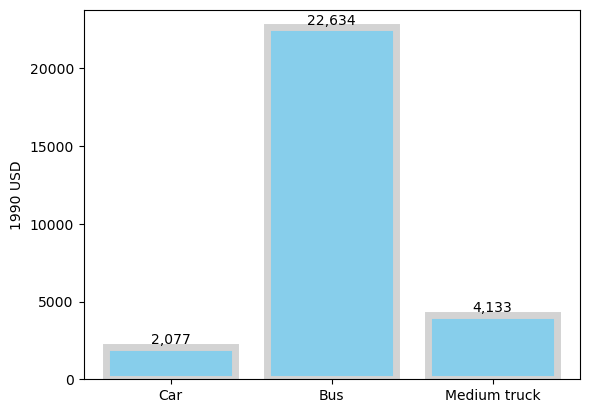

In [57]:
bars = plt.bar(df[(df['Fuel']=='BEV')]['Type'], df[(df['Fuel']=='BEV')]['1990$'], edgecolor='lightgray', color='skyblue', linewidth=5,)

# Add annotations
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:,.0f}',  # formatted without decimals
             ha='center', va='bottom')
plt.ylabel("1990 USD")


plt.show()

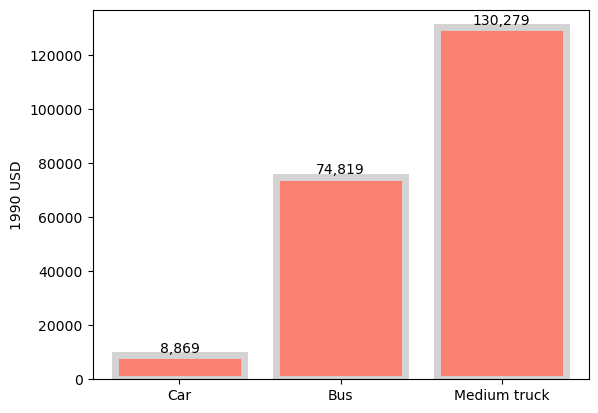

In [58]:
bars = plt.bar(df[(df['Fuel']=='FCEV')]['Type'], df[(df['Fuel']=='FCEV')]['1990$'], edgecolor='lightgray', color='salmon', linewidth=5,)

# Add annotations
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:,.0f}',  # formatted without decimals
             ha='center', va='bottom')
plt.ylabel("1990 USD")


plt.show()